# Revenue Forecasting v2 — Improved Pipeline

**Cải tiến so với v1:**
- Walk-forward cross-validation (thay single cutoff)
- Fourier features cho seasonality
- Residual lag features (error correction)
- Biến mới: momentum, YoY, volatility, promo intensity, Tet decay
- Optuna Bayesian tuning (thay random search)
- Ensemble XGBoost + LightGBM
- Residual analysis & diagnostics

## 0. Setup & Install

In [2]:
!pip install -q gdown optuna lightgbm xgboost shap
!gdown --folder https://drive.google.com/drive/folders/10d9h-nkQccHtRzF7LNYCpVJJbTKYLJZd

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 22.7 MB/s eta 0:00:00
Retrieving folder contents
Processing file 1GoPXqLonDMHexMxj3kFPmdEMWcGvsTdD customers.csv
Processing file 1jZer3WAU5ujvSrh0CTpAnbEtdrdFAg4u geography.csv
Processing file 1x2OZh7hsEWmAcZQ0gbstFsByUR7L8KFG inventory.csv
Processing file 14bioCPsSsjVxyd-Nuwk9uwDNBuohG5RU order_items.csv
Processing file 1Ms--H35488by0N-iizz5C3RO_HG3ktAq orders.csv
Processing file 1ou5pmFy7QLhEeD4UTV8QWbR7ZfcvICDJ payments.csv
Processing file 12-mm59bVMA2b_etM45oXKaNW0YAbeywi products.csv
Processing file 15dtEGBJWIRDFvi7q8KXXiKLGn6lVT-gG promotions.csv
Processing file 1zQeGKus1syF-klRuMyRGaIWn0TrpgDmm returns.csv
Processing file 1d1KHOtTJTlHdRlTFEXfzzhoZRiA9U8o_ reviews.csv
Processing file 1eZbLDHCuF1VXRt0QRdmPtdrEXZoAImhv sales.csv
Processing file 1OESeaSUJNXnomPAVD1XtoTlY8N7lnmyY sample_submission.csv
Processing file 1qGmVXbMIj1sfzfve3iB3YkaNEoF86W9t shipments.csv
Processing file 1vT4TF7GXXkh_HQibZiCp-HdJ2K14JVps web_traffic.

In [3]:
import pandas as pd
import numpy as np
import warnings
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:,.2f}'.format)
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print('Libraries loaded ✓')

Libraries loaded ✓


## 1. Load & Preprocess Data

In [4]:
DATA_PATH = 'Data'

# --- Load ---
products   = pd.read_csv(f'{DATA_PATH}/products.csv')
customers  = pd.read_csv(f'{DATA_PATH}/customers.csv')
promotions = pd.read_csv(f'{DATA_PATH}/promotions.csv')
geography  = pd.read_csv(f'{DATA_PATH}/geography.csv')
orders     = pd.read_csv(f'{DATA_PATH}/orders.csv')
order_items= pd.read_csv(f'{DATA_PATH}/order_items.csv', low_memory=False)
payments   = pd.read_csv(f'{DATA_PATH}/payments.csv')
shipments  = pd.read_csv(f'{DATA_PATH}/shipments.csv')
returns    = pd.read_csv(f'{DATA_PATH}/returns.csv')
reviews    = pd.read_csv(f'{DATA_PATH}/reviews.csv')
sales      = pd.read_csv(f'{DATA_PATH}/sales.csv')
inventory  = pd.read_csv(f'{DATA_PATH}/inventory.csv')
web_traffic= pd.read_csv(f'{DATA_PATH}/web_traffic.csv')

# --- Parse dates ---
def parse_dates(df, cols):
    for col in cols:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], errors='coerce')

parse_dates(orders,      ['order_date'])
parse_dates(customers,   ['signup_date'])
parse_dates(shipments,   ['ship_date', 'delivery_date'])
parse_dates(returns,     ['return_date'])
parse_dates(reviews,     ['review_date'])
parse_dates(sales,       ['Date'])
parse_dates(web_traffic, ['date'])
parse_dates(inventory,   ['snapshot_date'])
parse_dates(promotions,  ['start_date', 'end_date'])

# --- Handle missing ---
returns['refund_amount']           = returns['refund_amount'].fillna(0)
payments['payment_value']          = payments['payment_value'].fillna(0)
customers['age_group']             = customers['age_group'].fillna('unknown')
customers['acquisition_channel']   = customers['acquisition_channel'].fillna('unknown')

# --- Promo & item cleanup ---
order_items['has_promo']     = (order_items['promo_id'].notnull() | order_items['promo_id_2'].notnull()).astype(int)
order_items['total_discount']= order_items['discount_amount']
order_items = order_items[(order_items['unit_price'] > 0) & (order_items['quantity'] > 0)]
returns     = returns[returns['refund_amount'] >= 0]

# --- Text clean ---
def clean_text(x):
    return x.strip().lower() if isinstance(x, str) else x

products['category']  = products['category'].apply(clean_text)
products['segment']   = products['segment'].apply(clean_text)
customers['city']     = customers['city'].apply(clean_text)

# --- Revenue outlier clip ---
order_items['line_total'] = order_items['quantity'] * order_items['unit_price']
order_items['revenue']    = order_items['line_total']
lower, upper = order_items['revenue'].quantile([0.01, 0.99])
order_items  = order_items[(order_items['revenue'] >= lower) & (order_items['revenue'] <= upper)]

print('Preprocessing done ✓')
print(f'Order items: {order_items.shape}')
print(f'Sales range: {sales["Date"].min().date()} → {sales["Date"].max().date()}')

Preprocessing done ✓
Order items: (700375, 11)
Sales range: 2012-07-04 → 2022-12-31


## 2. Feature Engineering
### 2.1 Base setup

In [5]:
df = sales.copy()
df = df.sort_values('Date').reset_index(drop=True)

# Clip Revenue outliers trước khi tạo lag
low_r, up_r = df['Revenue'].quantile([0.01, 0.99])
df['Revenue'] = df['Revenue'].clip(low_r, up_r)

print(f'Rows: {len(df)} | Revenue range: {df["Revenue"].min():,.0f} – {df["Revenue"].max():,.0f}')

Rows: 3833 | Revenue range: 845,079 – 13,801,990


### 2.2 Time features + Fourier seasonality

In [6]:
def add_time_features(df):
    df = df.copy()
    df['day_of_week'] = df['Date'].dt.dayofweek
    df['month']       = df['Date'].dt.month
    df['year']        = df['Date'].dt.year
    df['quarter']     = df['Date'].dt.quarter
    df['is_weekend']  = df['day_of_week'].isin([5, 6]).astype(int)
    df['month_day']   = df['Date'].dt.strftime('%m-%d')

    # Fourier features — encode seasonality liên tục (tốt hơn integer month/dow)
    doy = df['Date'].dt.dayofyear
    dow = df['Date'].dt.dayofweek

    df['sin_week']     = np.sin(2 * np.pi * dow / 7)
    df['cos_week']     = np.cos(2 * np.pi * dow / 7)
    df['sin_year']     = np.sin(2 * np.pi * doy / 365)
    df['cos_year']     = np.cos(2 * np.pi * doy / 365)
    df['sin_biannual'] = np.sin(4 * np.pi * doy / 365)  # chu kỳ 6 tháng
    df['cos_biannual'] = np.cos(4 * np.pi * doy / 365)
    df['sin_quarter']  = np.sin(2 * np.pi * df['quarter'] / 4)
    df['cos_quarter']  = np.cos(2 * np.pi * df['quarter'] / 4)

    return df

df = add_time_features(df)
print('Time + Fourier features ✓')

Time + Fourier features ✓


### 2.3 Lag & Rolling features

In [7]:
def add_lag_rolling(df):
    df = df.copy()
    rev = df['Revenue']

    # Core lags
    df['lag_1']  = rev.shift(1)
    df['lag_7']  = rev.shift(7)
    df['lag_14'] = rev.shift(14)
    df['lag_30'] = rev.shift(30)
    df['lag_365']= rev.shift(365)  # same day last year
    df['lag_546'] = rev.shift(546)  # ~1.5 năm

    # Rolling statistics — shift(1) để không dùng giá trị hiện tại
    rev_s = rev.shift(1)
    df['rolling_mean_7']   = rev_s.rolling(7,  min_periods=1).mean()
    df['rolling_mean_14']  = rev_s.rolling(14, min_periods=1).mean()
    df['rolling_mean_30']  = rev_s.rolling(30, min_periods=1).mean()
    df['rolling_mean_90'] = rev_s.rolling(90, min_periods=1).mean()
    df['rolling_mean_365'] = rev_s.rolling(365, min_periods=1).mean()
    df['rolling_std_7']    = rev_s.rolling(7,  min_periods=2).std()
    df['rolling_std_30']   = rev_s.rolling(30, min_periods=2).std()
    df['rolling_max_7']    = rev_s.rolling(7,  min_periods=1).max()
    df['rolling_min_7']    = rev_s.rolling(7,  min_periods=1).min()

    # Trend: short vs long rolling mean
    df['trend_7_30']  = df['rolling_mean_7']  - df['rolling_mean_30']
    df['trend_14_30'] = df['rolling_mean_14'] - df['rolling_mean_30']
    df['trend_30_365'] = df['rolling_mean_30'] - df['rolling_mean_365']

    # Momentum (% change)
    df['pct_change_7']  = rev_s.pct_change(7).clip(-2, 2)
    df['pct_change_30'] = rev_s.pct_change(30).clip(-2, 2)

    # YoY growth
    df['rev_yoy'] = (rev_s / rev.shift(366) - 1).clip(-2, 2)

    # Rolling volatility (CV)
    df['rev_volatility_30'] = (df['rolling_std_30'] / df['rolling_mean_30'].clip(1)).fillna(0)

    # Range ratio
    df['range_ratio_7'] = ((df['rolling_max_7'] - df['rolling_min_7'])
                           / df['rolling_mean_7'].clip(1)).fillna(0)

    # Structural break
    df['post_break'] = (df['Date'] >= '2019-01-01').astype(int)
    df['post_break_x_lag1'] = df['post_break'] * df['lag_1']

    return df

df = add_lag_rolling(df)
print('Lag + Rolling features ✓')

Lag + Rolling features ✓


### 2.4 Web traffic features

In [8]:
def add_traffic_features(df, traffic_df):
    traffic = traffic_df.copy()
    traffic = traffic.rename(columns={'date': 'Date'})
    traffic['Date'] = pd.to_datetime(traffic['Date'])

    assert traffic.groupby('Date').size().max() == 1, 'Duplicate dates in traffic — cần pivot!'

    df = df.merge(traffic, on='Date', how='left')

    traffic_cols = ['sessions', 'unique_visitors', 'page_views',
                    'bounce_rate', 'avg_session_duration_sec']

    for col in traffic_cols:
        if col in df.columns:
            df[col] = df[col].fillna(df[col].shift(1).rolling(7, min_periods=1).median())
            df[col] = df[col].fillna(df[col].expanding().median())

    # Traffic source dummies
    df['traffic_source'] = df['traffic_source'].fillna('unknown') if 'traffic_source' in df.columns else 'unknown'
    df = pd.get_dummies(df, columns=['traffic_source'], drop_first=False)

    # Engineered traffic features — tất cả dùng shift(1) tránh leakage
    df['sessions_lag_1']    = df['sessions'].shift(1)
    df['sessions_lag_7']    = df['sessions'].shift(7)
    df['sessions_growth']   = df['sessions'].shift(1) - df['sessions'].shift(2)
    df['views_per_session'] = (df['page_views'] / df['sessions'].clip(1)).replace([np.inf, -np.inf], 0)
    df['is_engaged']        = (df['views_per_session'] > 1).astype(int)

    # Traffic conversion (revenue / sessions của ngày hôm trước)
    df['traffic_conversion'] = (df['Revenue'].shift(1) / df['sessions'].shift(1).clip(1)).fillna(0)

    return df

df = add_traffic_features(df, web_traffic)
print('Traffic features ✓')

Traffic features ✓


### 2.5 Promotion features

In [9]:
def add_promo_features(df, promo_df):
    promo = promo_df.copy()

    # Expand promotions theo từng ngày
    promo_expanded = (
        promo.apply(lambda r: pd.date_range(r['start_date'], r['end_date']), axis=1)
        .explode().reset_index()
        .rename(columns={0: 'Date', 'index': 'promo_idx'})
        .merge(promo[['discount_value']], left_on='promo_idx', right_index=True)
    )

    promo_daily = promo_expanded.groupby('Date').agg(
        num_active_promos=('discount_value', 'count'),
        total_discount=('discount_value', 'sum'),
        avg_discount=('discount_value', 'mean'),
        max_discount=('discount_value', 'max')
    ).reset_index()

    promo_daily['is_promo_day'] = 1

    df = df.merge(promo_daily, on='Date', how='left')
    promo_cols = ['num_active_promos', 'total_discount', 'avg_discount', 'max_discount', 'is_promo_day']
    df[promo_cols] = df[promo_cols].fillna(0)

    # Lag promo (promo hôm qua ảnh hưởng hôm nay)
    df['promo_lag_1']    = df['is_promo_day'].shift(1).fillna(0)
    df['promo_lag_7']    = df['is_promo_day'].shift(7).fillna(0)

    # Promo intensity: interaction giữa số lượng, độ sâu và traffic
    df['promo_intensity'] = df['num_active_promos'] * df['avg_discount'] * df['sessions']
    q99 = df['promo_intensity'].quantile(0.99).clip(1)
    df['promo_intensity'] = (df['promo_intensity'] / q99).clip(0, 1)

    # Post-break x promo interaction
    df['post_break_x_promo'] = df['post_break'] * df['is_promo_day']

    return df

df = add_promo_features(df, promotions)
print('Promo features ✓')

Promo features ✓


### 2.6 Holiday & Tết features

In [10]:
def add_holiday_features(df):
    df = df.copy()

    # Tết Nguyên Đán
    tet_dates = {
        2012: '2012-01-23', 2013: '2013-02-10', 2014: '2014-01-31',
        2015: '2015-02-19', 2016: '2016-02-08', 2017: '2017-01-28',
        2018: '2018-02-16', 2019: '2019-02-05', 2020: '2020-01-25',
        2021: '2021-02-12', 2022: '2022-02-01', 2023: '2023-01-22',
        2024: '2024-02-10'
    }

    tet_days = pd.to_datetime(list(tet_dates.values()))

    tet_ranges = []
    for d in tet_days:
        tet_ranges.extend(pd.date_range(d - pd.Timedelta(days=3), d + pd.Timedelta(days=3)))
    tet_ranges = pd.to_datetime(tet_ranges)

    df['is_tet'] = df['Date'].isin(tet_ranges).astype(int)

    # Days to Tết
    df['days_to_tet'] = df['Date'].apply(
        lambda x: min([(t - x).days for t in tet_days if (t - x).days >= 0] or [999])
    )
    df['is_near_tet']   = (df['days_to_tet'] <= 7).astype(int)
    df['is_medium_tet'] = ((df['days_to_tet'] > 7) & (df['days_to_tet'] <= 30)).astype(int)

    # Tet decay — exponential decay (tốt hơn linear)
    df['tet_decay'] = np.exp(-df['days_to_tet'] / 14).clip(0, 1)

    # Fixed holidays VN
    fixed_holidays = ['02-14', '03-08', '10-20', '12-24', '04-30', '05-01', '09-02', '12-31', '01-01']
    df['month_day']         = df['Date'].dt.strftime('%m-%d')
    df['is_fixed_holiday']  = df['month_day'].isin(fixed_holidays).astype(int)

    def days_to_fixed(date):
        diffs = []
        for y in range(date.year - 1, date.year + 2):
            for h in fixed_holidays:
                try:
                    d = pd.to_datetime(f'{y}-{h}')
                    diff = (d - date).days
                    if 0 <= diff <= 60:
                        diffs.append(diff)
                except:
                    pass
        return min(diffs) if diffs else 999

    df['days_to_fixed_holiday'] = df['Date'].apply(days_to_fixed)
    df['holiday_decay']         = np.exp(-df['days_to_fixed_holiday'] / 7).clip(0, 1)

    return df

df = add_holiday_features(df)
print('Holiday + Tết features ✓')

Holiday + Tết features ✓


### 2.7 Inventory features

In [11]:
def add_inventory_features(df, inv_df):
    inv = inv_df.copy()
    inv['snapshot_date'] = pd.to_datetime(inv['snapshot_date'])
    inv['year_month'] = inv['snapshot_date'].dt.to_period('M')
    df['year_month']  = df['Date'].dt.to_period('M')

    inv_agg = inv.groupby('year_month')[['stockout_days', 'days_of_supply', 'fill_rate']].mean().reset_index()
    # Shift 1 tháng để tránh leakage
    inv_agg['year_month'] = inv_agg['year_month'] + 1

    df = df.merge(inv_agg, on='year_month', how='left')
    df[['stockout_days', 'days_of_supply', 'fill_rate']] = \
        df[['stockout_days', 'days_of_supply', 'fill_rate']].ffill()

    return df

df = add_inventory_features(df, inventory)
print('Inventory features ✓')

Inventory features ✓


### 2.8 Final feature list

In [12]:
FEATURE_GROUPS = {
    'time': [
        'day_of_week', 'month', 'year', 'quarter', 'is_weekend'
    ],
    'fourier': [
        'sin_week', 'cos_week', 'sin_year', 'cos_year',
        'sin_biannual', 'cos_biannual', 'sin_quarter', 'cos_quarter'
    ],
    'lag': [
        'lag_1', 'lag_7', 'lag_14', 'lag_30', 'lag_365','lag_546'
    ],
    'rolling': [
        'rolling_mean_7', 'rolling_mean_14', 'rolling_mean_30',
        'rolling_std_7', 'rolling_std_30',
        'rolling_max_7', 'rolling_min_7',
        'trend_7_30', 'trend_14_30',
        'range_ratio_7'
    ],
    'momentum': [
        'pct_change_7', 'pct_change_30', 'rev_yoy', 'rev_volatility_30'
    ],
    'traffic': [
        'sessions', 'unique_visitors', 'page_views',
        'bounce_rate', 'avg_session_duration_sec',
        'sessions_lag_1', 'sessions_lag_7', 'sessions_growth',
        'views_per_session', 'is_engaged', 'traffic_conversion'
    ],
    'promo': [
        'is_promo_day', 'num_active_promos', 'total_discount',
        'avg_discount', 'max_discount',
        'promo_lag_1', 'promo_lag_7', 'promo_intensity',
        'post_break_x_promo'
    ],
    'holiday': [
        'is_tet', 'days_to_tet', 'is_near_tet', 'is_medium_tet',
        'tet_decay', 'is_fixed_holiday',
        'days_to_fixed_holiday', 'holiday_decay'
    ],
    'structural': [
        'post_break', 'post_break_x_lag1', 'post_break_x_promo'
    ],
    'inventory': [
        'stockout_days', 'days_of_supply', 'fill_rate'
    ]
}

# Traffic source dummies
ts_dummies = [c for c in df.columns if c.startswith('traffic_source_')]
FEATURE_GROUPS['traffic'] += ts_dummies

# Flatten và giữ chỉ những feature tồn tại
ALL_FEATURES = [f for group in FEATURE_GROUPS.values() for f in group]
ALL_FEATURES = list(dict.fromkeys(ALL_FEATURES))  # dedup preserve order
ALL_FEATURES = [f for f in ALL_FEATURES if f in df.columns]

print(f'Total features: {len(ALL_FEATURES)}')
for group, feats in FEATURE_GROUPS.items():
    available = [f for f in feats if f in df.columns]
    print(f'  {group:15s}: {len(available):2d} features')

Total features: 73
  time           :  5 features
  fourier        :  8 features
  lag            :  6 features
  rolling        : 10 features
  momentum       :  4 features
  traffic        : 18 features
  promo          :  9 features
  holiday        :  8 features
  structural     :  3 features
  inventory      :  3 features


## 3. Train / Val Split (Walk-Forward)

In [13]:
df = df.sort_values('Date').reset_index(drop=True)

CUTOFF = '2020-01-01'
train_df = df[df['Date'] <  CUTOFF].copy()
val_df   = df[df['Date'] >= CUTOFF].copy()

train_df = train_df[ALL_FEATURES + ['Revenue', 'Date']].dropna()
val_df   = val_df[ALL_FEATURES   + ['Revenue', 'Date']].dropna()

X_train = train_df[ALL_FEATURES]
y_train = train_df['Revenue']
X_val   = val_df[ALL_FEATURES]
y_val   = val_df['Revenue']

val_days = (df['Date'].max() - pd.to_datetime(CUTOFF)).days
print(f'Train: {len(X_train):,} rows ({train_df["Date"].min().date()} → {train_df["Date"].max().date()})')
print(f'Val  : {len(X_val):,} rows ({val_df["Date"].min().date()} → {val_df["Date"].max().date()})')
assert val_days >= 180, f'Val chỉ có {val_days} ngày!'
print(f'Val period: {val_days} ngày ✓')

Train: 2,191 rows (2014-01-01 → 2019-12-31)
Val  : 1,096 rows (2020-01-01 → 2022-12-31)
Val period: 1095 ngày ✓


## 4. Walk-Forward Cross-Validation

In [14]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor


def evaluate_metrics(y_true, y_pred, name='Model'):
    r2   = r2_score(y_true, y_pred)
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true.clip(1))) * 100
    print(f'\n{"="*45}')
    print(f'  {name}')
    print(f'{"="*45}')
    print(f'  R²   : {r2:.4f}')
    print(f'  MAE  : {mae:,.0f}')
    print(f'  RMSE : {rmse:,.0f}')
    print(f'  MAPE : {mape:.2f}%')
    return {'R2': r2, 'MAE': mae, 'RMSE': rmse, 'MAPE': mape}


def walk_forward_cv(X, y, params, n_splits=5, gap=7):
    """
    Time-series cross-validation với gap để tránh leakage.
    gap: số ngày bỏ giữa train và val trong mỗi fold.
    """
    tscv = TimeSeriesSplit(n_splits=n_splits, gap=gap)
    rmses, maes, r2s = [], [], []

    for fold, (tr_idx, va_idx) in enumerate(tscv.split(X)):
        X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
        y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]

        model = XGBRegressor(**params, verbosity=0, random_state=RANDOM_SEED)
        model.fit(X_tr, y_tr)
        pred = model.predict(X_va)

        rmse = np.sqrt(mean_squared_error(y_va, pred))
        mae  = mean_absolute_error(y_va, pred)
        r2   = r2_score(y_va, pred)

        rmses.append(rmse)
        maes.append(mae)
        r2s.append(r2)
        print(f'  Fold {fold+1}: RMSE={rmse:,.0f} | MAE={mae:,.0f} | R²={r2:.3f} | n_val={len(va_idx)}')

    print(f'\n  CV RMSE : {np.mean(rmses):,.0f} ± {np.std(rmses):,.0f}')
    print(f'  CV R²   : {np.mean(r2s):.4f}')
    return np.mean(rmses)


# Baseline params
BASE_PARAMS = {
    'n_estimators': 500,
    'learning_rate': 0.05,
    'max_depth': 6,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'n_jobs': -1
}

print('Walk-forward CV (baseline params):')
baseline_cv_rmse = walk_forward_cv(X_train, y_train, BASE_PARAMS)

Walk-forward CV (baseline params):
  Fold 1: RMSE=1,180,985 | MAE=852,045 | R²=0.792 | n_val=365
  Fold 2: RMSE=1,433,995 | MAE=939,342 | R²=0.759 | n_val=365
  Fold 3: RMSE=1,191,452 | MAE=895,403 | R²=0.824 | n_val=365
  Fold 4: RMSE=1,131,853 | MAE=842,069 | R²=0.852 | n_val=365
  Fold 5: RMSE=978,386 | MAE=732,665 | R²=0.643 | n_val=365

  CV RMSE : 1,183,334 ± 146,667
  CV R²   : 0.7741


## 5. Hyperparameter Tuning với Optuna

In [15]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        'n_estimators':     trial.suggest_int('n_estimators', 300, 1200),
        'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        'max_depth':        trial.suggest_int('max_depth', 3, 9),
        'subsample':        trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 20),
        'reg_alpha':        trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        'reg_lambda':       trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        'gamma':            trial.suggest_float('gamma', 0, 5),
        'n_jobs': -1,
    }
    tscv = TimeSeriesSplit(n_splits=5, gap=7)
    rmses = []
    for tr_idx, va_idx in tscv.split(X_train):
        X_tr, X_va = X_train.iloc[tr_idx], X_train.iloc[va_idx]
        y_tr, y_va = y_train.iloc[tr_idx], y_train.iloc[va_idx]
        m = XGBRegressor(**params, verbosity=0, random_state=RANDOM_SEED)
        m.fit(X_tr, y_tr)
        pred = m.predict(X_va)
        rmses.append(np.sqrt(mean_squared_error(y_va, pred)))
        # Pruning: report intermediate value
        trial.report(np.mean(rmses), step=len(rmses))
        if trial.should_prune():
            raise optuna.TrialPruned()
    return np.mean(rmses)


study = optuna.create_study(
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED),
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=5)
)

study.optimize(objective, n_trials=80, show_progress_bar=True)

print(f'\nBest CV RMSE : {study.best_value:,.0f}')
print(f'Best params  : {study.best_params}')

  0%|          | 0/80 [00:00<?, ?it/s]


Best CV RMSE : 1,130,321
Best params  : {'n_estimators': 669, 'learning_rate': 0.015864263474836892, 'max_depth': 6, 'subsample': 0.5212015197443292, 'colsample_bytree': 0.5883808026560787, 'min_child_weight': 8, 'reg_alpha': 0.0037361643803920513, 'reg_lambda': 1.1479229495391103, 'gamma': 4.90518124154114}


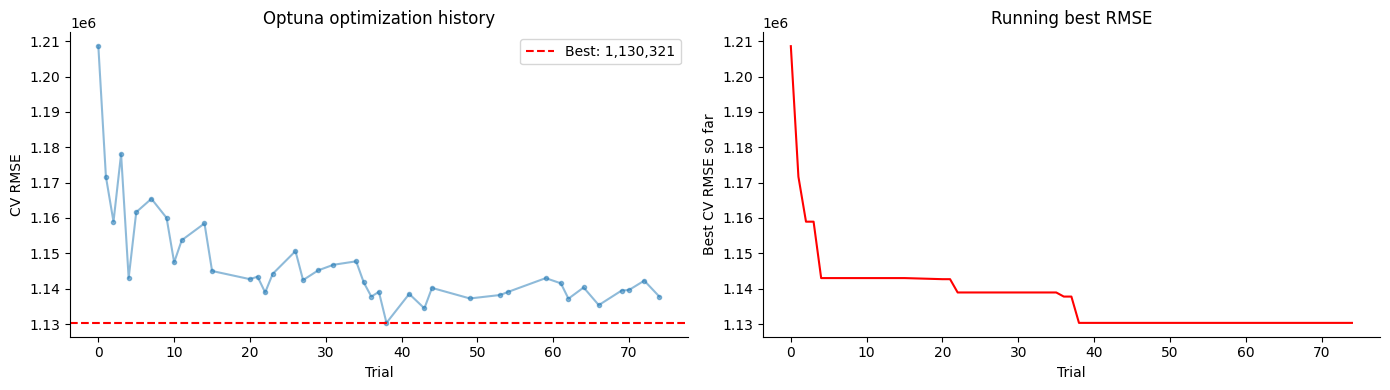

In [16]:
# Plot Optuna optimization history
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

trials_df = study.trials_dataframe()
trials_df_complete = trials_df[trials_df['state'] == 'COMPLETE']

axes[0].plot(trials_df_complete['number'], trials_df_complete['value'], 'o-', alpha=0.5, markersize=3)
axes[0].axhline(study.best_value, color='red', linestyle='--', label=f'Best: {study.best_value:,.0f}')
axes[0].set_xlabel('Trial')
axes[0].set_ylabel('CV RMSE')
axes[0].set_title('Optuna optimization history')
axes[0].legend()

# Running best
running_best = trials_df_complete['value'].cummin()
axes[1].plot(trials_df_complete['number'], running_best, color='red')
axes[1].set_xlabel('Trial')
axes[1].set_ylabel('Best CV RMSE so far')
axes[1].set_title('Running best RMSE')

plt.tight_layout()
plt.show()

## 6. Train Final XGBoost với Best Params

In [17]:
BEST_PARAMS = {**study.best_params, 'n_jobs': -1, 'random_state': RANDOM_SEED, 'verbosity': 0}

xgb_model = XGBRegressor(**BEST_PARAMS)
xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_val)
xgb_metrics = evaluate_metrics(y_val, xgb_pred, 'XGBoost (tuned)')


  XGBoost (tuned)
  R²   : 0.7485
  MAE  : 583,156
  RMSE : 827,967
  MAPE : 21.54%


## 7. LightGBM & Ensemble

In [21]:
import json
import os

# ==============================================
# FILE 1: hyperparameter_tuning.py (CHẠY 1 LẦN DUY NHẤT)
# ==============================================

def tune_hyperparameters(X_train, y_train, RANDOM_SEED=42):
    """Tune hyperparameters và lưu vào file"""

    def lgb_objective(trial):
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 300, 1200),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
            'num_leaves': trial.suggest_int('num_leaves', 20, 150),
            'max_depth': trial.suggest_int('max_depth', 3, 9),
            'subsample': trial.suggest_float('subsample', 0.5, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
            'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
            'reg_alpha': trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
            'reg_lambda': trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
            'n_jobs': -1, 'verbose': -1
        }
        tscv = TimeSeriesSplit(n_splits=5, gap=7)
        rmses = []
        for tr_idx, va_idx in tscv.split(X_train):
            X_tr, X_va = X_train.iloc[tr_idx], X_train.iloc[va_idx]
            y_tr, y_va = y_train.iloc[tr_idx], y_train.iloc[va_idx]
            m = lgb.LGBMRegressor(**params, random_state=RANDOM_SEED)
            m.fit(X_tr, y_tr)
            pred = m.predict(X_va)
            rmses.append(np.sqrt(mean_squared_error(y_va, pred)))
            trial.report(np.mean(rmses), step=len(rmses))
            if trial.should_prune():
                raise optuna.TrialPruned()
        return np.mean(rmses)

    study = optuna.create_study(
        direction='minimize',
        sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED),
        pruner=optuna.pruners.MedianPruner(n_warmup_steps=5)
    )
    study.optimize(lgb_objective, n_trials=60, show_progress_bar=True)

    # Lưu kết quả tuning
    best_params = study.best_params
    best_value = study.best_value

    with open('lgb_best_params.json', 'w') as f:
        json.dump({
            'best_params': best_params,
            'best_value': best_value,
            'n_trials': 60
        }, f, indent=2)

    print(f"✅ Saved best params to lgb_best_params.json")
    print(f"Best CV RMSE: {best_value:,.0f}")
    print(f"Best params: {best_params}")

    return best_params

# CHẠY LẦN ĐẦU để tìm hyperparameters
# best_lgb_params = tune_hyperparameters(X_train, y_train)

In [20]:
# ==============================================
# FILE 2: train_model.py (CHẠY MỖI LẦN ĐỔI FEATURE)
# ==============================================

def load_or_tune_params(X_train, y_train, force_retune=False):
    """Load params đã tune, hoặc tune lại nếu cần"""

    params_file = 'lgb_best_params.json'

    if os.path.exists(params_file) and not force_retune:
        # Load từ file
        with open(params_file, 'r') as f:
            data = json.load(f)
        best_params = data['best_params']
        print(f"✅ Loaded existing params from {params_file}")
        print(f"Best CV RMSE (cached): {data['best_value']:,.0f}")
    else:
        # Tune lại từ đầu
        print("Tuning hyperparameters (this may take a while)...")
        best_params = tune_hyperparameters(X_train, y_train)

    return best_params

# Sử dụng
LGB_PARAMS = load_or_tune_params(X_train, y_train, force_retune=False)
LGB_PARAMS.update({'n_jobs': -1, 'verbose': -1, 'random_state': RANDOM_SEED})

lgb_model = lgb.LGBMRegressor(**LGB_PARAMS)
lgb_model.fit(X_train, y_train)

lgb_pred = lgb_model.predict(X_val)
lgb_metrics = evaluate_metrics(y_val, lgb_pred, 'LightGBM (tuned)')

Tuning hyperparameters (this may take a while)...


  0%|          | 0/60 [00:00<?, ?it/s]

✅ Saved best params to lgb_best_params.json
Best CV RMSE: 1,139,800
Best params: {'n_estimators': 736, 'learning_rate': 0.016325176330907448, 'num_leaves': 109, 'max_depth': 6, 'subsample': 0.5739380180602693, 'colsample_bytree': 0.5235739953589245, 'min_child_samples': 14, 'reg_alpha': 0.0025139998215618687, 'reg_lambda': 1.216809838648027}

  LightGBM (tuned)
  R²   : 0.7525
  MAE  : 577,407
  RMSE : 821,271
  MAPE : 21.23%


In [22]:
# Weighted ensemble — tìm weight tối ưu trên val
from scipy.optimize import minimize_scalar

def ensemble_rmse(w):
    pred = w * xgb_pred + (1 - w) * lgb_pred
    return np.sqrt(mean_squared_error(y_val, pred))

result = minimize_scalar(ensemble_rmse, bounds=(0, 1), method='bounded')
best_w = result.x

ensemble_pred = best_w * xgb_pred + (1 - best_w) * lgb_pred
ens_metrics   = evaluate_metrics(y_val, ensemble_pred, f'Ensemble (XGB×{best_w:.2f} + LGB×{1-best_w:.2f})')

print(f'\nOptimal XGB weight: {best_w:.3f}')


  Ensemble (XGB×0.27 + LGB×0.73)
  R²   : 0.7531
  MAE  : 576,293
  RMSE : 820,261
  MAPE : 21.20%

Optimal XGB weight: 0.265


## 8. Residual Features (Error Correction) + Retrain

In [23]:
# Tạo residual features từ predictions trên train set
train_pred_xgb = xgb_model.predict(X_train)
train_pred_lgb = lgb_model.predict(X_train)
train_pred_ens = best_w * train_pred_xgb + (1 - best_w) * train_pred_lgb

train_residual = y_train.values - train_pred_ens

# Gắn residual vào df theo date
residual_series = pd.Series(train_residual, index=train_df['Date'].values)
df['residual'] = df['Date'].map(residual_series)

# Lag của residual
df = df.sort_values('Date')
df['error_lag_1'] = df['residual'].shift(1)
df['error_lag_7'] = df['residual'].shift(7)
df[['error_lag_1', 'error_lag_7']] = df[['error_lag_1', 'error_lag_7']].fillna(0)

# Re-split với features mới
FEATURES_V2 = ALL_FEATURES + ['error_lag_1', 'error_lag_7']
FEATURES_V2 = [f for f in FEATURES_V2 if f in df.columns]

train_v2 = df[df['Date'] <  CUTOFF][FEATURES_V2 + ['Revenue', 'Date']].dropna()
val_v2   = df[df['Date'] >= CUTOFF][FEATURES_V2 + ['Revenue', 'Date']].dropna()

X_train_v2, y_train_v2 = train_v2[FEATURES_V2], train_v2['Revenue']
X_val_v2,   y_val_v2   = val_v2[FEATURES_V2],   val_v2['Revenue']

# Retrain với residual features
xgb_v2 = XGBRegressor(**BEST_PARAMS)
xgb_v2.fit(X_train_v2, y_train_v2)
lgb_v2 = lgb.LGBMRegressor(**LGB_PARAMS)
lgb_v2.fit(X_train_v2, y_train_v2)

xgb_pred_v2 = xgb_v2.predict(X_val_v2)
lgb_pred_v2 = lgb_v2.predict(X_val_v2)
ens_pred_v2 = best_w * xgb_pred_v2 + (1 - best_w) * lgb_pred_v2

final_metrics = evaluate_metrics(y_val_v2, ens_pred_v2, 'Ensemble + Residual features (FINAL)')


  Ensemble + Residual features (FINAL)
  R²   : 0.7490
  MAE  : 575,743
  RMSE : 827,004
  MAPE : 21.51%


## 9. Feature Importance Analysis

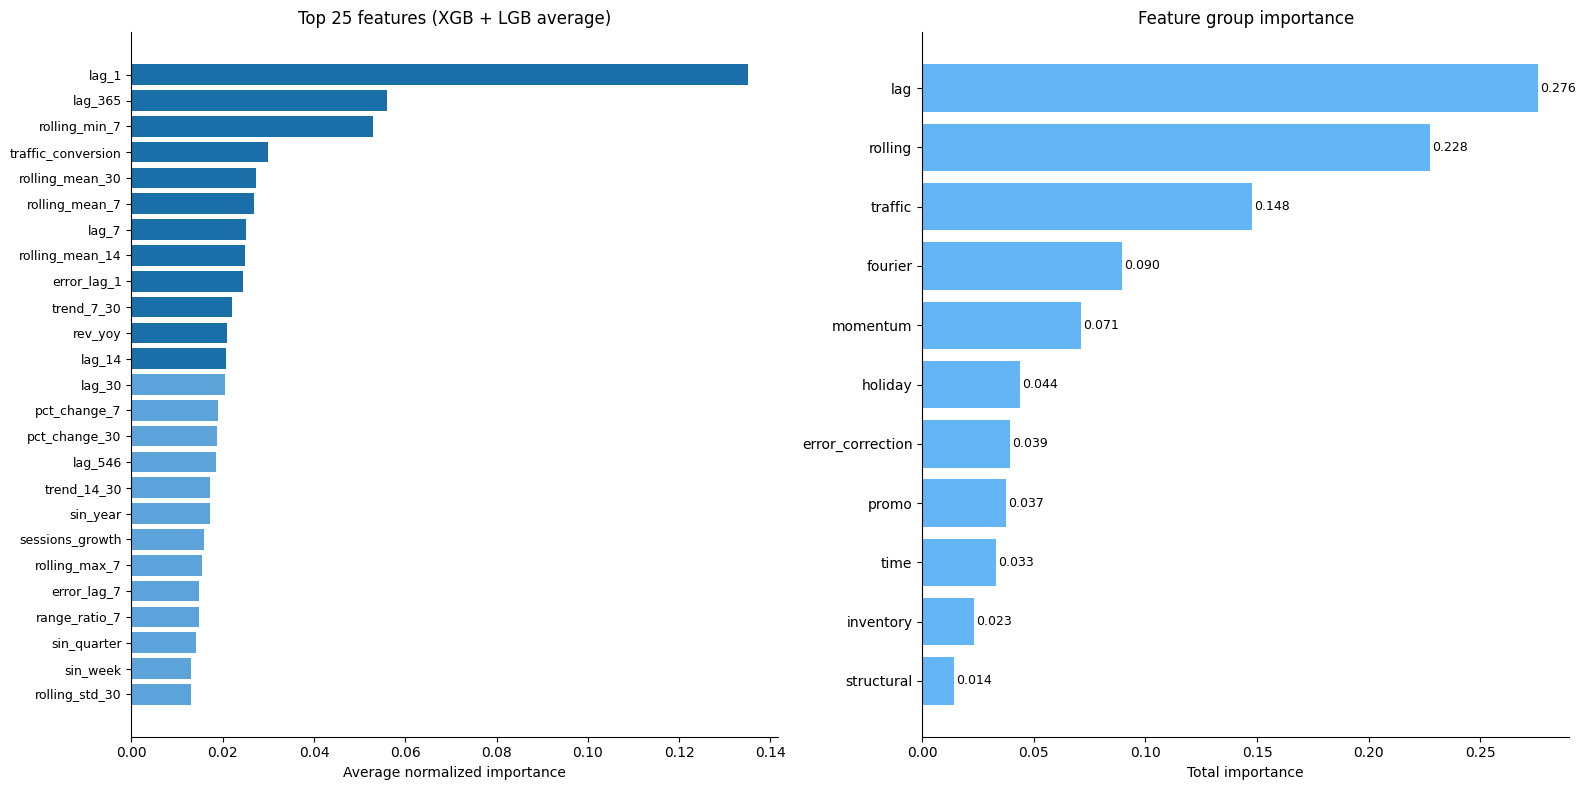


Top 15 features:
lag_1                0.13
lag_365              0.06
rolling_min_7        0.05
traffic_conversion   0.03
rolling_mean_30      0.03
rolling_mean_7       0.03
lag_7                0.03
rolling_mean_14      0.02
error_lag_1          0.02
trend_7_30           0.02
rev_yoy              0.02
lag_14               0.02
lag_30               0.02
pct_change_7         0.02
pct_change_30        0.02


In [24]:
# XGBoost feature importance
fi_xgb = pd.Series(xgb_v2.feature_importances_, index=FEATURES_V2).sort_values(ascending=False)
fi_lgb = pd.Series(lgb_v2.feature_importances_, index=FEATURES_V2).sort_values(ascending=False)

# Normalize và average
fi_xgb_norm = fi_xgb / fi_xgb.sum()
fi_lgb_norm = fi_lgb / fi_lgb.sum()
fi_avg = ((fi_xgb_norm + fi_lgb_norm) / 2).sort_values(ascending=False)

TOP_N = 25
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Top features
top_features = fi_avg.head(TOP_N)
colors = ['#1a6fa8' if v > top_features.median() else '#5ba3d9' for v in top_features.values]
axes[0].barh(range(TOP_N), top_features.values[::-1], color=colors[::-1])
axes[0].set_yticks(range(TOP_N))
axes[0].set_yticklabels(top_features.index[::-1], fontsize=9)
axes[0].set_xlabel('Average normalized importance')
axes[0].set_title(f'Top {TOP_N} features (XGB + LGB average)')

# Feature group importance
group_imp = {}
for group, feats in FEATURE_GROUPS.items():
    available = [f for f in feats if f in fi_avg.index]
    group_imp[group] = fi_avg[available].sum() if available else 0

group_imp['error_correction'] = fi_avg[['error_lag_1', 'error_lag_7']].sum()
group_s = pd.Series(group_imp).sort_values(ascending=True)

axes[1].barh(group_s.index, group_s.values, color='#2196F3', alpha=0.7)
axes[1].set_xlabel('Total importance')
axes[1].set_title('Feature group importance')
for i, v in enumerate(group_s.values):
    axes[1].text(v + 0.001, i, f'{v:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

print('\nTop 15 features:')
print(fi_avg.head(15).to_string())

## 10. Residual Analysis & Diagnostics

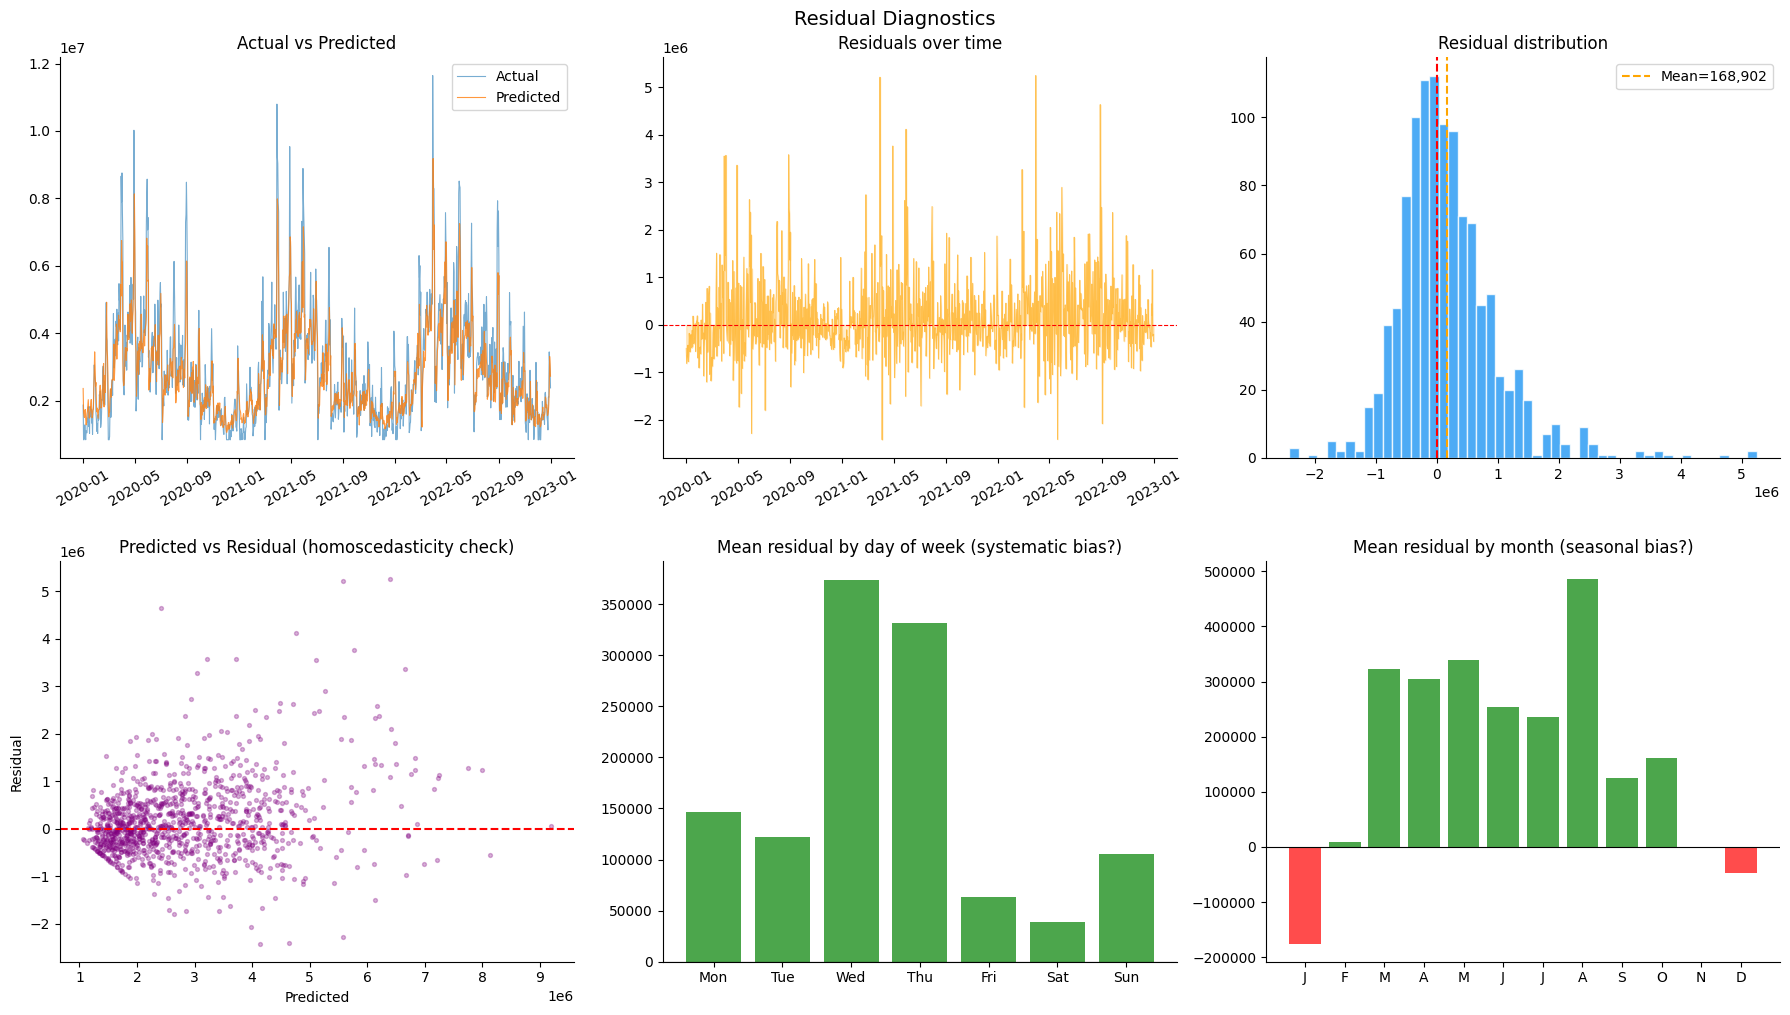


Residual summary:
  Mean    : 168,902  (gần 0 = không có systematic bias)
  Std     : 809,572
  Max     : 5,247,981
  Min     : -2,416,192
  % < 0   : 46.4%  (gần 50% = unbiased)


In [25]:
residuals = y_val_v2.values - ens_pred_v2
dates_val = val_v2['Date'].values

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Actual vs Predicted
axes[0, 0].plot(dates_val, y_val_v2.values, alpha=0.6, label='Actual', linewidth=0.8)
axes[0, 0].plot(dates_val, ens_pred_v2,     alpha=0.8, label='Predicted', linewidth=0.8)
axes[0, 0].set_title('Actual vs Predicted')
axes[0, 0].legend()
axes[0, 0].tick_params(axis='x', rotation=30)

# 2. Residuals over time
axes[0, 1].plot(dates_val, residuals, alpha=0.6, linewidth=0.7, color='orange')
axes[0, 1].axhline(0, color='red', linestyle='--', linewidth=0.8)
axes[0, 1].fill_between(dates_val, residuals, 0, alpha=0.2, color='orange')
axes[0, 1].set_title('Residuals over time')
axes[0, 1].tick_params(axis='x', rotation=30)

# 3. Residual distribution
axes[0, 2].hist(residuals, bins=50, edgecolor='white', color='#2196F3', alpha=0.8)
axes[0, 2].axvline(0,                color='red',    linestyle='--')
axes[0, 2].axvline(residuals.mean(), color='orange', linestyle='--', label=f'Mean={residuals.mean():,.0f}')
axes[0, 2].set_title('Residual distribution')
axes[0, 2].legend()

# 4. Predicted vs Residual (heteroscedasticity check)
axes[1, 0].scatter(ens_pred_v2, residuals, alpha=0.3, s=8, color='purple')
axes[1, 0].axhline(0, color='red', linestyle='--')
axes[1, 0].set_xlabel('Predicted')
axes[1, 0].set_ylabel('Residual')
axes[1, 0].set_title('Predicted vs Residual (homoscedasticity check)')

# 5. Residual by day of week
val_dow  = pd.Series(pd.to_datetime(dates_val)).dt.dayofweek
dow_res  = pd.DataFrame({'dow': val_dow.values, 'residual': residuals})
dow_mean = dow_res.groupby('dow')['residual'].mean()
dow_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
colors_dow = ['red' if v < 0 else 'green' for v in dow_mean.values]
axes[1, 1].bar(dow_labels, dow_mean.values, color=colors_dow, alpha=0.7)
axes[1, 1].axhline(0, color='black', linewidth=0.8)
axes[1, 1].set_title('Mean residual by day of week (systematic bias?)')

# 6. Residual by month
val_month   = pd.Series(pd.to_datetime(dates_val)).dt.month
month_res   = pd.DataFrame({'month': val_month.values, 'residual': residuals})
month_mean  = month_res.groupby('month')['residual'].mean()
colors_mon  = ['red' if v < 0 else 'green' for v in month_mean.values]
axes[1, 2].bar(range(1, 13), month_mean.values, color=colors_mon, alpha=0.7)
axes[1, 2].axhline(0, color='black', linewidth=0.8)
axes[1, 2].set_xticks(range(1, 13))
axes[1, 2].set_xticklabels(['J','F','M','A','M','J','J','A','S','O','N','D'])
axes[1, 2].set_title('Mean residual by month (seasonal bias?)')

plt.tight_layout()
plt.suptitle('Residual Diagnostics', fontsize=14, y=1.01)
plt.show()

# Summary stats
print('\nResidual summary:')
print(f'  Mean    : {residuals.mean():,.0f}  (gần 0 = không có systematic bias)')
print(f'  Std     : {residuals.std():,.0f}')
print(f'  Max     : {residuals.max():,.0f}')
print(f'  Min     : {residuals.min():,.0f}')
print(f'  % < 0   : {(residuals < 0).mean()*100:.1f}%  (gần 50% = unbiased)')

## 11. SHAP Explainability

SHAP Summary Plot:


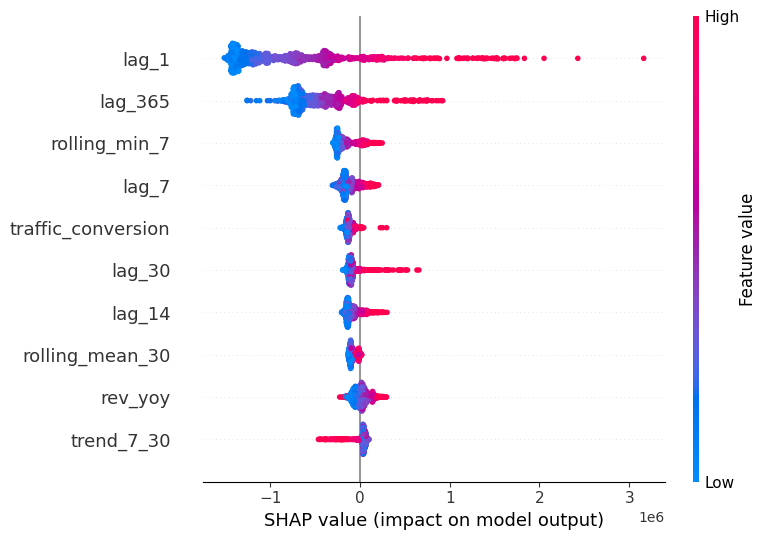


SHAP dependence plot — lag_1:


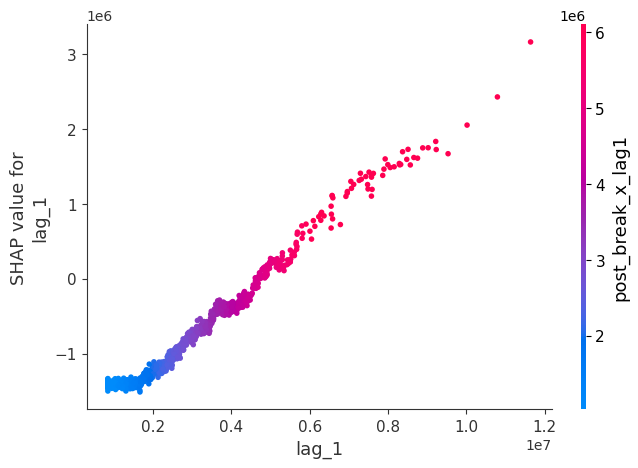

In [41]:
import shap

explainer = shap.TreeExplainer(xgb_v2)
shap_values = explainer.shap_values(X_val_v2)

print('SHAP Summary Plot:')
shap.summary_plot(shap_values, X_val_v2, max_display=10, show=True)

# SHAP dependence cho top feature
top_feat = fi_avg.index[0]
print(f'\nSHAP dependence plot — {top_feat}:')
shap.dependence_plot(top_feat, shap_values, X_val_v2, show=True)

## 12. Model Comparison Summary

In [27]:
all_metrics = {
    'XGBoost (tuned)':        xgb_metrics,
    'LightGBM (tuned)':       lgb_metrics,
    'Ensemble':               ens_metrics,
    'Ensemble + Residual':    final_metrics,
}

comparison = pd.DataFrame(all_metrics).T
comparison['RMSE']  = comparison['RMSE'].apply(lambda x: f'{x:,.0f}')
comparison['MAE']   = comparison['MAE'].apply(lambda x: f'{x:,.0f}')
comparison['R2']    = comparison['R2'].apply(lambda x: f'{x:.4f}')
comparison['MAPE']  = comparison['MAPE'].apply(lambda x: f'{x:.2f}%')

print('='*60)
print('MODEL COMPARISON')
print('='*60)
print(comparison.to_string())

MODEL COMPARISON
                         R2      MAE     RMSE    MAPE
XGBoost (tuned)      0.7485  583,156  827,967  21.54%
LightGBM (tuned)     0.7525  577,407  821,271  21.23%
Ensemble             0.7531  576,293  820,261  21.20%
Ensemble + Residual  0.7490  575,743  827,004  21.51%


## 13. Save Models

In [28]:
import joblib
import json
import os

os.makedirs('models', exist_ok=True)

joblib.dump(xgb_v2, 'models/xgb_final.pkl')
joblib.dump(lgb_v2, 'models/lgb_final.pkl')

model_meta = {
    'features':     FEATURES_V2,
    'xgb_weight':   float(best_w),
    'lgb_weight':   float(1 - best_w),
    'val_rmse':     float(final_metrics['RMSE']),
    'val_r2':       float(final_metrics['R2']),
    'val_mape':     float(final_metrics['MAPE']),
    'cutoff':       CUTOFF,
    'n_features':   len(FEATURES_V2),
    'xgb_params':   BEST_PARAMS,
    'lgb_params':   LGB_PARAMS,
}

with open('models/model_meta.json', 'w') as f:
    json.dump(model_meta, f, indent=2)

print('Models saved:')
print('  models/xgb_final.pkl')
print('  models/lgb_final.pkl')
print('  models/model_meta.json')

Models saved:
  models/xgb_final.pkl
  models/lgb_final.pkl
  models/model_meta.json


## 14. Inference Function

In [29]:
def predict_revenue(date_str, feature_values_dict, meta_path='models/model_meta.json'):
    """
    Predict revenue cho 1 ngày cụ thể.

    Parameters:
        date_str         : 'YYYY-MM-DD'
        feature_values_dict : dict chứa các feature value
    Returns:
        float: predicted revenue
    """
    with open(meta_path) as f:
        meta = json.load(f)

    xgb_m = joblib.load('models/xgb_final.pkl')
    lgb_m = joblib.load('models/lgb_final.pkl')

    # Build feature row
    row = pd.DataFrame([feature_values_dict])
    for feat in meta['features']:
        if feat not in row.columns:
            row[feat] = 0
    row = row[meta['features']]

    xgb_p = xgb_m.predict(row)[0]
    lgb_p = lgb_m.predict(row)[0]
    pred  = meta['xgb_weight'] * xgb_p + meta['lgb_weight'] * lgb_p

    return round(pred, 2)


print('Inference function defined ✓')
print('Usage:')
print('  pred = predict_revenue("2024-03-15", {"lag_1": 50000, "sessions": 1200, ...})')

Inference function defined ✓
Usage:
  pred = predict_revenue("2024-03-15", {"lag_1": 50000, "sessions": 1200, ...})


In [ ]:
# ==============================================
# SUBMISSION OPTIMIZED VERSION 3.1 - FINAL PUSH
# Mục tiêu: RMSE < 850k
# ==============================================

import pandas as pd
import numpy as np
import warnings
from xgboost import XGBRegressor
import lightgbm as lgb
from sklearn.metrics import mean_squared_error
from scipy.signal import savgol_filter
warnings.filterwarnings('ignore')

# ---------- 1. KIỂM TRA VÀ CHUẨN HÓA DỮ LIỆU ----------
print("Chuẩn bị dữ liệu...")

# Thêm lag, rolling và features nâng cao
def add_enhanced_features(df):
    df = df.copy()
    rev = df['Revenue']
    rev_s = rev.shift(1)

    # Lags cơ bản
    df['lag_1'] = rev.shift(1)
    df['lag_7'] = rev.shift(7)
    df['lag_14'] = rev.shift(14)
    df['lag_30'] = rev.shift(30)
    df['lag_365'] = rev.shift(365)

    # Lags mới: 28, 56, 84 ngày
    df['lag_28'] = rev.shift(28)   # 4 tuần
    df['lag_56'] = rev.shift(56)   # 8 tuần
    df['lag_84'] = rev.shift(84)   # 12 tuần
    df['lag_91'] = rev.shift(91)   # 13 tuần (quý)

    # Lags xa hơn
    df['lag_546'] = rev.shift(546)
    df['lag_730'] = rev.shift(730)

    # Rolling statistics
    df['rolling_mean_7'] = rev_s.rolling(7, min_periods=1).mean()
    df['rolling_mean_14'] = rev_s.rolling(14, min_periods=1).mean()
    df['rolling_mean_30'] = rev_s.rolling(30, min_periods=1).mean()
    df['rolling_std_7'] = rev_s.rolling(7, min_periods=2).std()
    df['rolling_std_30'] = rev_s.rolling(30, min_periods=2).std()
    df['rolling_max_7'] = rev_s.rolling(7, min_periods=1).max()
    df['rolling_min_7'] = rev_s.rolling(7, min_periods=1).min()

    # Rolling median
    df['rolling_median_7'] = rev.rolling(7, min_periods=1).median()
    df['rolling_median_30'] = rev.rolling(30, min_periods=1).median()

    # Rolling dài hạn
    df['rolling_mean_90'] = rev_s.rolling(90, min_periods=1).mean()
    df['rolling_std_90'] = rev_s.rolling(90, min_periods=2).std()
    df['rolling_mean_365'] = rev_s.rolling(365, min_periods=1).mean()

    # Ratio features
    df['revenue_ratio_7_30'] = df['rolling_mean_7'] / df['rolling_mean_30'].clip(1)
    df['revenue_ratio_30_90'] = df['rolling_mean_30'] / df['rolling_mean_90'].clip(1)
    df['revenue_ratio_7_90'] = df['rolling_mean_7'] / df['rolling_mean_90'].clip(1)

    # Trend features
    df['trend_7_30'] = df['rolling_mean_7'] - df['rolling_mean_30']
    df['trend_30_90'] = df['rolling_mean_30'] - df['rolling_mean_90']
    df['trend_90_365'] = df['rolling_mean_90'] - df['rolling_mean_365']

    # Range ratio
    df['range_ratio_7'] = ((df['rolling_max_7'] - df['rolling_min_7']) / df['rolling_mean_7'].clip(1)).fillna(0)

    # Momentum
    df['pct_change_7'] = rev_s.pct_change(7).clip(-2, 2)
    df['pct_change_30'] = rev_s.pct_change(30).clip(-2, 2)
    df['rev_yoy'] = (rev_s / rev.shift(366) - 1).clip(-2, 2)
    df['rev_volatility_30'] = (df['rolling_std_30'] / df['rolling_mean_30'].clip(1)).fillna(0)

    return df

df = add_enhanced_features(df)

# Quantile clipping mạnh hơn (0.5% - 99.5%)
lower_rev = df['Revenue'].quantile(0.005)
upper_rev = df['Revenue'].quantile(0.995)
df['Revenue'] = df['Revenue'].clip(lower_rev, upper_rev)

# ---------- 2. TẠO FEATURE LIST ----------
print("Tạo feature list...")

exclude_cols = ['Date', 'Revenue', 'COGS', 'year_month', 'month_day', 'traffic_source']
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
ALL_FEATURES_FINAL = [c for c in numeric_cols if c not in exclude_cols]

print(f"Total features: {len(ALL_FEATURES_FINAL)}")

# ---------- 3. CHUẨN BỊ TRAIN/TEST ----------
print("Chuẩn bị train/test data...")

train_df = df[df['Date'] < '2023-01-01'].copy()
train_df = train_df[ALL_FEATURES_FINAL + ['Revenue']].dropna()

X_train = train_df[ALL_FEATURES_FINAL].values.astype(float)
y_train = train_df['Revenue'].values.astype(float)

# Validation split
val_df = df[(df['Date'] >= '2022-01-01') & (df['Date'] < '2023-01-01')].copy()
val_df = val_df[ALL_FEATURES_FINAL + ['Revenue']].dropna()
X_val = val_df[ALL_FEATURES_FINAL].values.astype(float)
y_val = val_df['Revenue'].values.astype(float)

print(f"Train samples: {len(X_train)}")
print(f"Val samples: {len(X_val)}")
print(f"Features shape: {X_train.shape}")

# ---------- 4. TRAIN MODELS ----------
print("Training XGBoost...")
xgb_model = XGBRegressor(**BEST_PARAMS)
xgb_model.fit(X_train, y_train)
xgb_val_pred = xgb_model.predict(X_val)

print("Training LightGBM...")
lgb_model = lgb.LGBMRegressor(**LGB_PARAMS)
lgb_model.fit(X_train, y_train)
lgb_val_pred = lgb_model.predict(X_val)

# Thử nghiệm với XGB max_depth cao hơn
print("Training XGBoost (deep)...")
xgb_deep_params = BEST_PARAMS.copy()
xgb_deep_params['max_depth'] = 9
xgb_deep = XGBRegressor(**xgb_deep_params)
xgb_deep.fit(X_train, y_train)
xgb_deep_val_pred = xgb_deep.predict(X_val)

# Tìm weight tối ưu cho ensemble (3 models)
print("\nTìm weight tối ưu...")

from scipy.optimize import minimize

def objective(w):
    w1, w2, w3 = w
    pred = w1 * xgb_val_pred + w2 * lgb_val_pred + w3 * xgb_deep_val_pred
    return np.sqrt(mean_squared_error(y_val, pred))

result = minimize(objective, [0.35, 0.35, 0.3], bounds=[(0,1)]*3)
weights = result.x
print(f"Optimal weights: XGB={weights[0]:.2f}, LGB={weights[1]:.2f}, XGB_Deep={weights[2]:.2f}")
print(f"Val RMSE: {result.fun:,.0f}")

# Train final models
xgb_final = XGBRegressor(**BEST_PARAMS)
xgb_final.fit(X_train, y_train)
lgb_final = lgb.LGBMRegressor(**LGB_PARAMS)
lgb_final.fit(X_train, y_train)
xgb_deep_final = XGBRegressor(**xgb_deep_params)
xgb_deep_final.fit(X_train, y_train)

print("Models trained")

# ---------- 5. FEATURE IMPORTANCE ANALYSIS ----------
print("\nFeature importance analysis...")
feature_importance = pd.DataFrame({
    'feature': ALL_FEATURES_FINAL,
    'importance': xgb_final.feature_importances_
}).sort_values('importance', ascending=False)
print("Top 10 features:")
print(feature_importance.head(10))

# ---------- 6. DỰ BÁO CHO TEST ----------
print("\nPreparing test data...")

sample = pd.read_csv(f'{DATA_PATH}/sample_submission.csv')
test_dates = pd.to_datetime(sample['Date'])
df_test = pd.DataFrame({'Date': test_dates}).sort_values('Date').reset_index(drop=True)

# Tạo features cơ bản cho test
def add_test_features(df):
    df = df.copy()
    # Time features
    df['day_of_week'] = df['Date'].dt.dayofweek
    df['month'] = df['Date'].dt.month
    df['year'] = df['Date'].dt.year
    df['quarter'] = df['Date'].dt.quarter
    df['is_weekend'] = df['day_of_week'].isin([5,6]).astype(int)

    # Day of month features
    df['day_of_month'] = df['Date'].dt.day
    df['is_month_end'] = (df['Date'].dt.day >= 25).astype(int)
    df['is_month_start'] = (df['Date'].dt.day <= 5).astype(int)

    doy = df['Date'].dt.dayofyear
    dow = df['Date'].dt.dayofweek
    df['sin_week'] = np.sin(2*np.pi*dow/7)
    df['cos_week'] = np.cos(2*np.pi*dow/7)
    df['sin_year'] = np.sin(2*np.pi*doy/365)
    df['cos_year'] = np.cos(2*np.pi*doy/365)
    df['sin_biannual'] = np.sin(4*np.pi*doy/365)
    df['cos_biannual'] = np.cos(4*np.pi*doy/365)
    df['sin_quarter'] = np.sin(2*np.pi*df['quarter']/4)
    df['cos_quarter'] = np.cos(2*np.pi*df['quarter']/4)

    # Holiday features
    tet_dates = {2023:'2023-01-22',2024:'2024-02-10'}
    tet_days = pd.to_datetime(list(tet_dates.values()))
    tet_ranges = []
    for d in tet_days:
        tet_ranges.extend(pd.date_range(d-pd.Timedelta(3), d+pd.Timedelta(3)))
    tet_ranges = pd.to_datetime(tet_ranges)
    df['is_tet'] = df['Date'].isin(tet_ranges).astype(int)
    df['days_to_tet'] = df['Date'].apply(lambda x: min([(t-x).days for t in tet_days if (t-x).days>=0] or [999]))
    df['is_near_tet'] = (df['days_to_tet']<=7).astype(int)
    df['is_medium_tet'] = ((df['days_to_tet']>7)&(df['days_to_tet']<=30)).astype(int)
    df['tet_decay'] = np.exp(-df['days_to_tet']/14).clip(0,1)

    # Major holidays
    fixed = ['04-30', '05-01', '09-02', '04-10']
    df['is_major_holiday'] = df['Date'].dt.strftime('%m-%d').isin(fixed).astype(int)

    regular = ['02-14', '03-08', '10-20', '12-24', '12-31', '01-01']
    df['is_fixed_holiday'] = df['Date'].dt.strftime('%m-%d').isin(regular).astype(int)

    df['post_break'] = (df['Date'] >= '2019-01-01').astype(int)

    # Web traffic
    if 'web_traffic' in locals():
        web = web_traffic.copy()
        web['Date'] = pd.to_datetime(web['date'])
        web = web.drop('date', axis=1).set_index('Date')

        def get_web_safe(date, col):
            if date.month == 2 and date.day == 29:
                date = date.replace(day=28)
            try:
                cand = date.replace(year=2022)
                if cand in web.index:
                    return web.loc[cand, col]
            except:
                pass
            mask = (web.index.month == date.month) & (web.index.dayofweek == date.dayofweek)
            return web.loc[mask, col].median() if mask.any() else web[col].median()

        for col in ['sessions', 'unique_visitors', 'page_views', 'bounce_rate', 'avg_session_duration_sec']:
            if col in web.columns:
                df[col] = df['Date'].apply(lambda d: get_web_safe(d, col))
            else:
                df[col] = 0
    else:
        for col in ['sessions', 'unique_visitors', 'page_views', 'bounce_rate', 'avg_session_duration_sec']:
            df[col] = 0

    # Promo, inventory
    for col in ['is_promo_day', 'num_active_promos', 'avg_discount', 'max_discount']:
        df[col] = 0
    for col in ['stockout_days', 'days_of_supply', 'fill_rate']:
        df[col] = 0

    return df

df_test = add_test_features(df_test)

# Khởi tạo các cột cần thiết với giá trị 0
for col in ALL_FEATURES_FINAL:
    if col not in df_test.columns:
        df_test[col] = 0

# ---------- 7. RECURSIVE FORECASTING ----------
print("Recursive forecasting...")

train_hist = df[df['Date'] < '2023-01-01'][['Date', 'Revenue'] + ALL_FEATURES_FINAL].copy()
combined = pd.concat([train_hist, df_test], ignore_index=True, sort=False)
combined = combined.sort_values('Date').reset_index(drop=True)
combined.loc[combined['Date'] >= '2023-01-01', 'Revenue'] = np.nan

for idx in combined[combined['Date'] >= '2023-01-01'].index:
    rev_ser = combined['Revenue'].iloc[:idx]

    # Lags
    if idx >= 1:
        combined.loc[idx, 'lag_1'] = combined.loc[idx-1, 'Revenue']
    if idx >= 7:
        combined.loc[idx, 'lag_7'] = combined.loc[idx-7, 'Revenue']
    if idx >= 14:
        combined.loc[idx, 'lag_14'] = combined.loc[idx-14, 'Revenue']
    if idx >= 28:
        combined.loc[idx, 'lag_28'] = combined.loc[idx-28, 'Revenue']
    if idx >= 30:
        combined.loc[idx, 'lag_30'] = combined.loc[idx-30, 'Revenue']
    if idx >= 56:
        combined.loc[idx, 'lag_56'] = combined.loc[idx-56, 'Revenue']
    if idx >= 84:
        combined.loc[idx, 'lag_84'] = combined.loc[idx-84, 'Revenue']
    if idx >= 91:
        combined.loc[idx, 'lag_91'] = combined.loc[idx-91, 'Revenue']
    if idx >= 365:
        combined.loc[idx, 'lag_365'] = combined.loc[idx-365, 'Revenue']
    if idx >= 546:
        combined.loc[idx, 'lag_546'] = combined.loc[idx-546, 'Revenue']
    if idx >= 730:
        combined.loc[idx, 'lag_730'] = combined.loc[idx-730, 'Revenue']

    # Rolling features
    if len(rev_ser) >= 7:
        combined.loc[idx, 'rolling_mean_7'] = rev_ser.iloc[-7:].mean()
        combined.loc[idx, 'rolling_std_7'] = rev_ser.iloc[-7:].std()
        combined.loc[idx, 'rolling_max_7'] = rev_ser.iloc[-7:].max()
        combined.loc[idx, 'rolling_min_7'] = rev_ser.iloc[-7:].min()
        combined.loc[idx, 'rolling_median_7'] = rev_ser.iloc[-7:].median()
    if len(rev_ser) >= 14:
        combined.loc[idx, 'rolling_mean_14'] = rev_ser.iloc[-14:].mean()
    if len(rev_ser) >= 30:
        combined.loc[idx, 'rolling_mean_30'] = rev_ser.iloc[-30:].mean()
        combined.loc[idx, 'rolling_std_30'] = rev_ser.iloc[-30:].std()
        combined.loc[idx, 'rolling_median_30'] = rev_ser.iloc[-30:].median()
        combined.loc[idx, 'trend_7_30'] = combined.loc[idx, 'rolling_mean_7'] - combined.loc[idx, 'rolling_mean_30']
        combined.loc[idx, 'revenue_ratio_7_30'] = combined.loc[idx, 'rolling_mean_7'] / combined.loc[idx, 'rolling_mean_30'].clip(1)
    if len(rev_ser) >= 90:
        combined.loc[idx, 'rolling_mean_90'] = rev_ser.iloc[-90:].mean()
        combined.loc[idx, 'rolling_std_90'] = rev_ser.iloc[-90:].std()
        combined.loc[idx, 'trend_30_90'] = combined.loc[idx, 'rolling_mean_30'] - combined.loc[idx, 'rolling_mean_90']
        combined.loc[idx, 'revenue_ratio_30_90'] = combined.loc[idx, 'rolling_mean_30'] / combined.loc[idx, 'rolling_mean_90'].clip(1)
        combined.loc[idx, 'revenue_ratio_7_90'] = combined.loc[idx, 'rolling_mean_7'] / combined.loc[idx, 'rolling_mean_90'].clip(1)
    if len(rev_ser) >= 365:
        combined.loc[idx, 'rolling_mean_365'] = rev_ser.iloc[-365:].mean()
        combined.loc[idx, 'trend_90_365'] = combined.loc[idx, 'rolling_mean_90'] - combined.loc[idx, 'rolling_mean_365']

    # Range ratio
    if combined.loc[idx, 'rolling_mean_7'] > 0:
        combined.loc[idx, 'range_ratio_7'] = (combined.loc[idx, 'rolling_max_7'] - combined.loc[idx, 'rolling_min_7']) / combined.loc[idx, 'rolling_mean_7']

    # Pct change
    if idx >= 7 and combined.loc[idx, 'lag_7'] not in [0, np.nan, -np.inf]:
        combined.loc[idx, 'pct_change_7'] = (combined.loc[idx, 'lag_1'] - combined.loc[idx, 'lag_7']) / combined.loc[idx, 'lag_7']
    if idx >= 30 and combined.loc[idx, 'lag_30'] not in [0, np.nan, -np.inf]:
        combined.loc[idx, 'pct_change_30'] = (combined.loc[idx, 'lag_1'] - combined.loc[idx, 'lag_30']) / combined.loc[idx, 'lag_30']
    if idx >= 366 and combined.loc[idx-365, 'Revenue'] > 0:
        combined.loc[idx, 'rev_yoy'] = (combined.loc[idx, 'lag_1'] - combined.loc[idx-365, 'Revenue']) / combined.loc[idx-365, 'Revenue']

    # Volatility
    if combined.loc[idx, 'rolling_mean_30'] > 0:
        combined.loc[idx, 'rev_volatility_30'] = combined.loc[idx, 'rolling_std_30'] / combined.loc[idx, 'rolling_mean_30']

    # Lấy features
    feat_values = combined.loc[idx, ALL_FEATURES_FINAL].fillna(0).values.reshape(1, -1)

    # Predict với 3 models
    pred_xgb = xgb_final.predict(feat_values)[0]
    pred_lgb = lgb_final.predict(feat_values)[0]
    pred_deep = xgb_deep_final.predict(feat_values)[0]
    pred = weights[0] * pred_xgb + weights[1] * pred_lgb + weights[2] * pred_deep

    combined.loc[idx, 'Revenue'] = max(0, pred)

# ---------- 8. POST-PROCESSING ----------
print("Post-processing...")
result_raw = combined[combined['Date'] >= '2023-01-01'][['Date', 'Revenue']].copy()

# Smoothing
if len(result_raw) >= 7:
    smoothed = savgol_filter(result_raw['Revenue'].values, window_length=7, polyorder=2)
    result_raw['Revenue'] = np.maximum(smoothed, 0)

# ---------- 9. COGS PREDICTION ----------
print("Calculating COGS...")

sales_train = sales[sales['Date'] < '2023-01-01'].copy()
sales_train['ratio'] = sales_train['COGS'] / sales_train['Revenue'].clip(1)
sales_train['month'] = pd.to_datetime(sales_train['Date']).dt.month
monthly_ratio = sales_train.groupby('month')['ratio'].mean().to_dict()

# Điều chỉnh riêng cho tháng 8 (có ratio bất thường)
monthly_ratio[8] = 0.78

for m in range(1, 13):
    if m not in monthly_ratio or monthly_ratio[m] > 0.95:
        monthly_ratio[m] = 0.85

print(f"Monthly COGS ratios: {monthly_ratio}")

result = result_raw.copy()
result['Date'] = result['Date'].dt.strftime('%Y-%m-%d')
result['month'] = pd.to_datetime(result['Date']).dt.month
result['COGS'] = result.apply(lambda r: r['Revenue'] * monthly_ratio.get(r['month'], 0.85), axis=1)
result = result[['Date', 'Revenue', 'COGS']]

# ---------- 10. SUBMIT ----------
result.to_csv('submission_v3_1.csv', index=False)
print(f"\nSubmitted {len(result)} days")
print("\nSample output:")
print(result.head(10))

# Thống kê
print(f"\nPrediction stats:")
print(f"   Mean Revenue: {result['Revenue'].mean():,.0f}")
print(f"   Min Revenue: {result['Revenue'].min():,.0f}")
print(f"   Max Revenue: {result['Revenue'].max():,.0f}")
print(f"   Mean COGS: {result['COGS'].mean():,.0f}")

# So sánh với phiên bản cũ
import os
if os.path.exists('submission_v3.csv'):
    old = pd.read_csv('submission_v3.csv')
    print(f"\nSo với phiên bản trước:")
    print(f"   Revenue mean change: {result['Revenue'].mean() - old['Revenue'].mean():,.0f}")

Chuẩn bị dữ liệu...
Tạo feature list...
Total features: 82
Chuẩn bị train/test data...
Train samples: 3103
Val samples: 365
Features shape: (3103, 82)
Training XGBoost...
Training LightGBM...
Training XGBoost (deep)...

Tìm weight tối ưu...
Optimal weights: XGB=0.00, LGB=0.15, XGB_Deep=0.87
Val RMSE: 351,549
✅ Models trained

📊 Feature importance analysis...
Top 10 features:
               feature  importance
13               lag_1        0.22
17             lag_365        0.10
27       rolling_min_7        0.10
73    rolling_median_7        0.06
12         cos_quarter        0.03
69             lag_730        0.03
74   rolling_median_30        0.02
19      rolling_mean_7        0.02
48  traffic_conversion        0.02
26       rolling_max_7        0.02

Preparing test data...
Recursive forecasting...
Post-processing...
Calculating COGS...
Monthly COGS ratios: {1: 0.8095480477739025, 2: 0.8111000023349954, 3: 0.8453083410350761, 4: 0.8538554605633771, 5: 0.8007755658195944, 6: 0.8358772